# <center> **Machine Learning for Social Data Science** <center/>

## <center> **Problem Set 2** <center/> 

### <center> *Solution 1 - all-MiniLM-L6-v2* <center/>

### **Topic Modelling**

#### **Load in Data**

In [6]:
import pandas as pd

COF = pd.read_csv("../Data/Levelling_Up_COF_Corpus.csv")

In [7]:
text = COF.Text.tolist()

#### **Embeddings**

In [8]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(text)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### **Dimensionality Reduction with UMAP**

In [10]:
import umap

umap_model = umap.UMAP(n_neighbors = 5, min_dist = 0.00, metric = "cosine", random_state = 42)

umap_embeddings = umap_model.fit_transform(embeddings)

c:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### **Clustering with HDBSCAN**

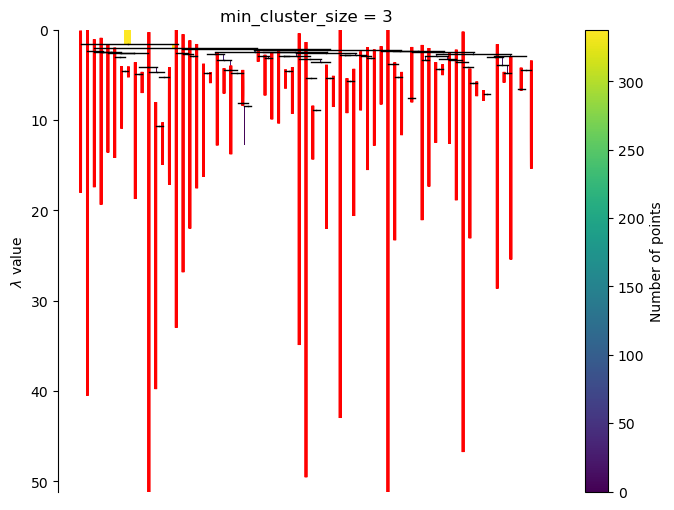

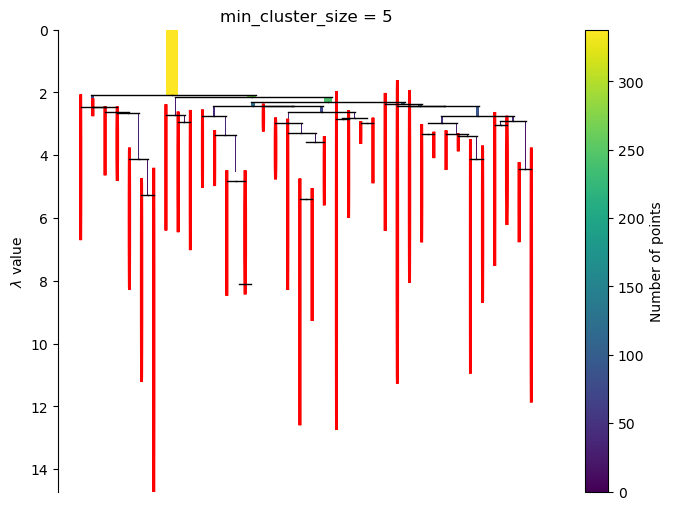

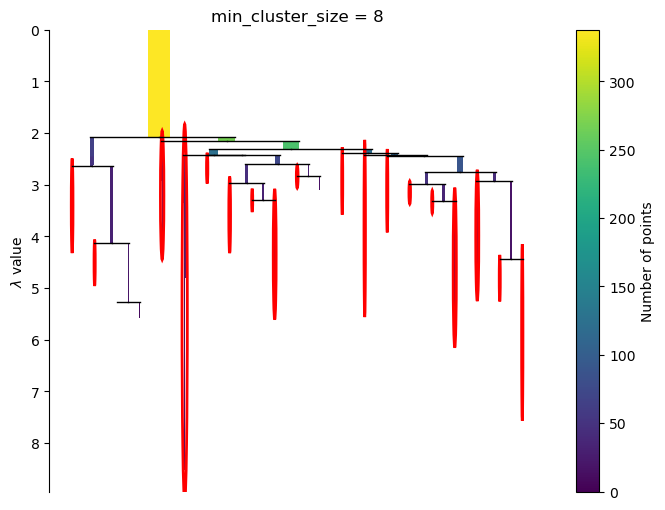

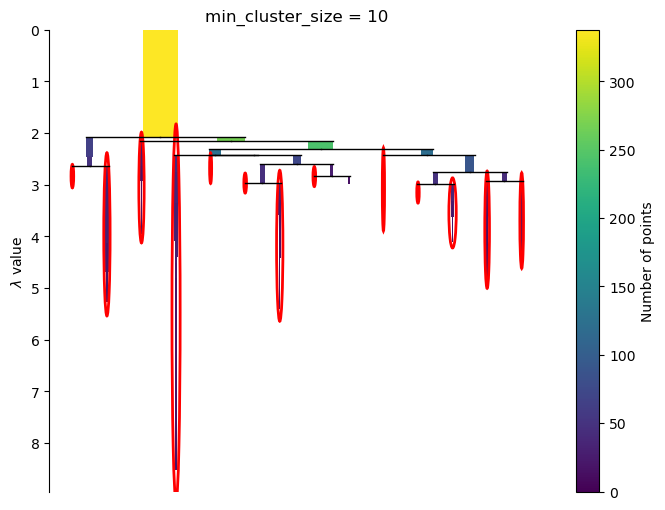

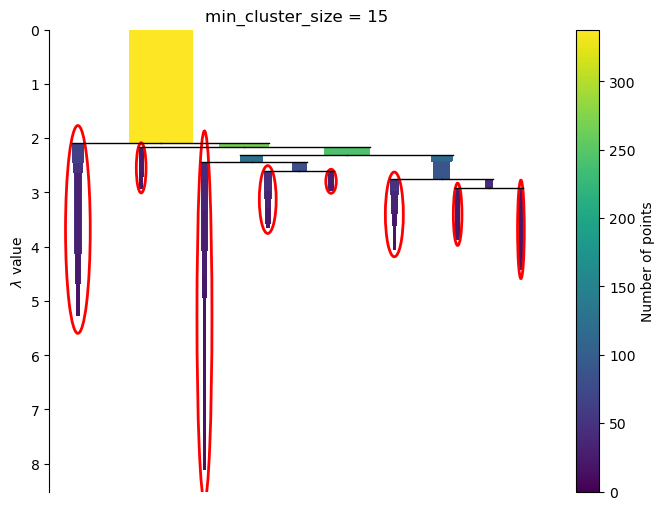

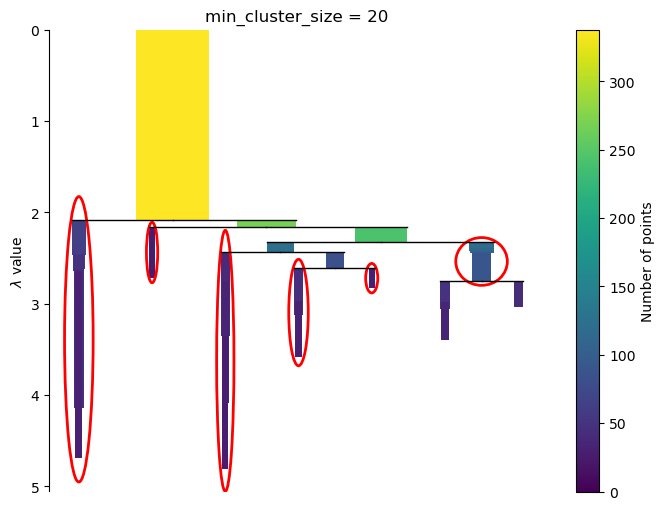

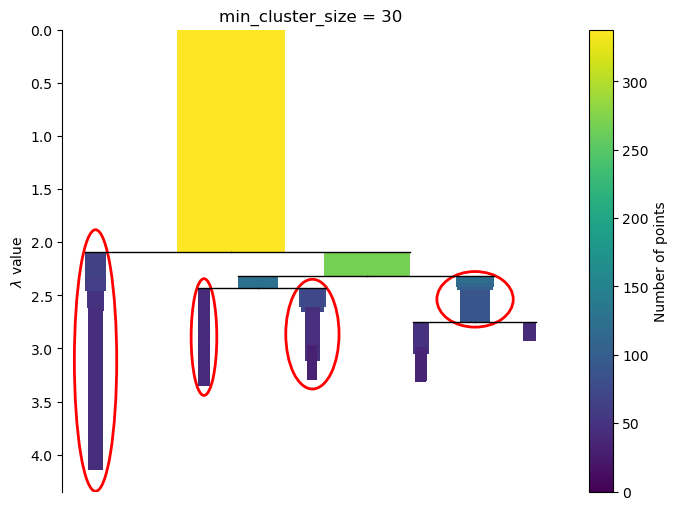

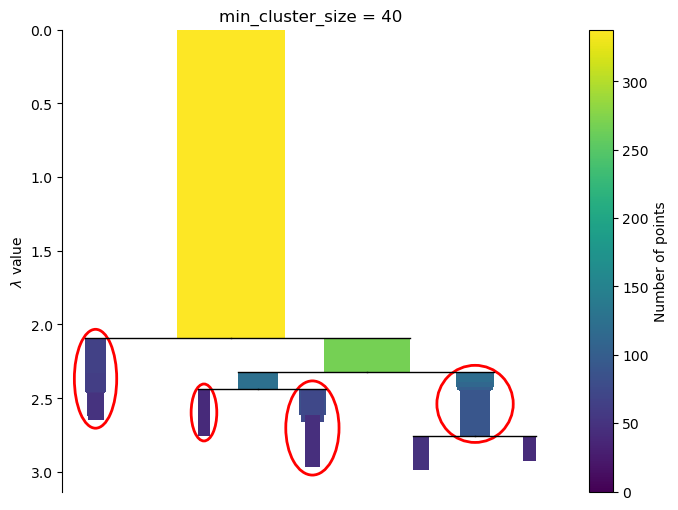

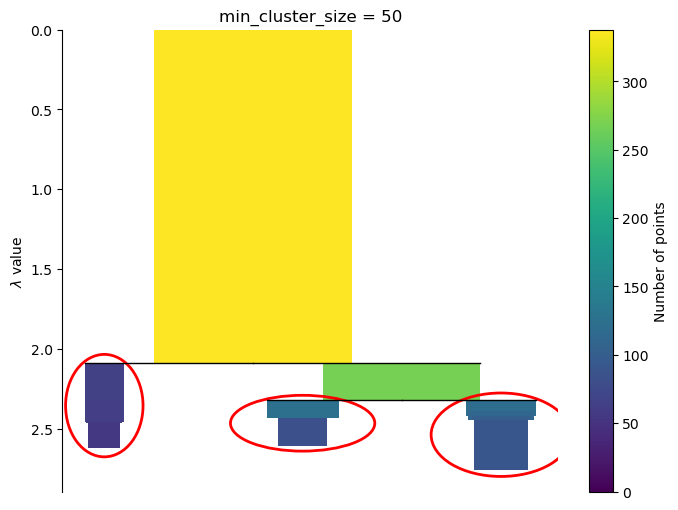

In [11]:
#Condensed Trees - Minimum Cluster Size
import os
import hdbscan
import matplotlib.pyplot as plt

save_folder = "../Raw Figures"
os.makedirs(save_folder, exist_ok = True)

min_cluster_sizes = [3, 5, 8, 10, 15, 20, 30, 40, 50]

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = min_size,
        min_samples = 1,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    plt.figure(figsize = (8, 6))
    clusterer.condensed_tree_.plot(select_clusters = True)
    plt.title(f"min_cluster_size = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"Condensed_tree_cluster_{min_size}.png"))

plt.show()

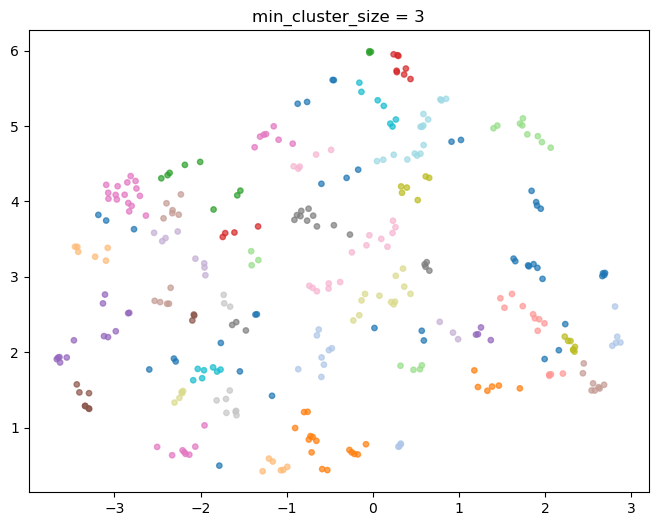

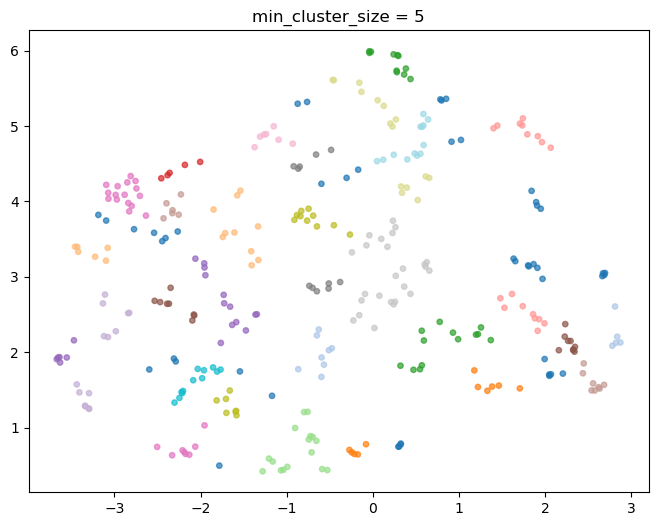

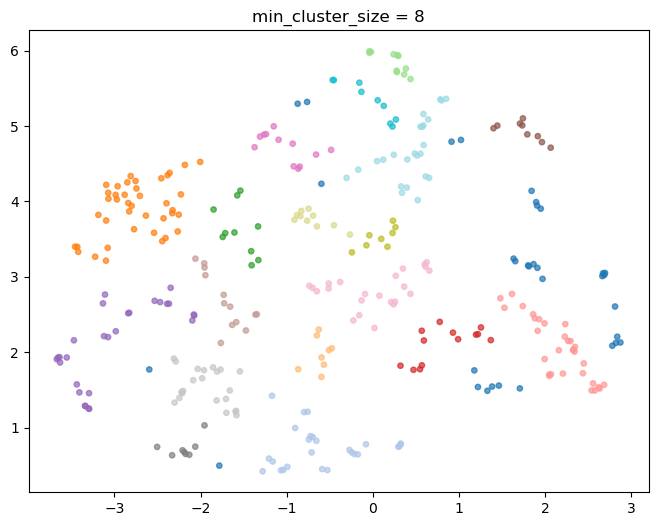

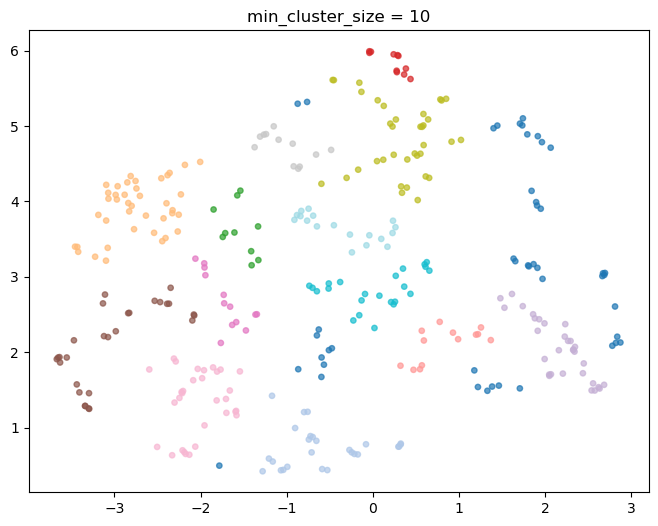

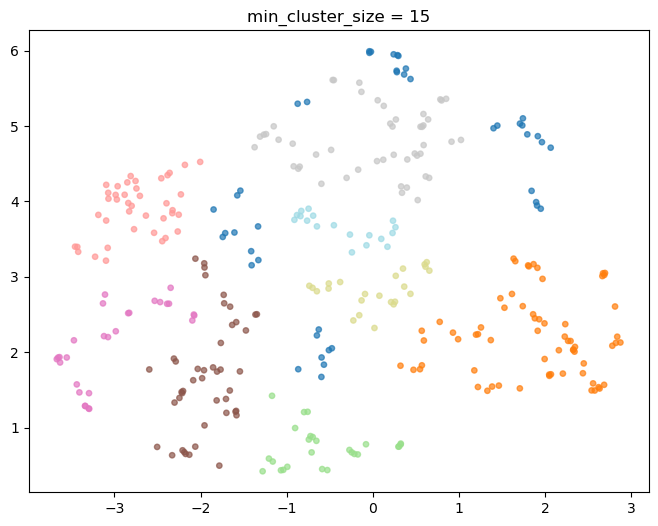

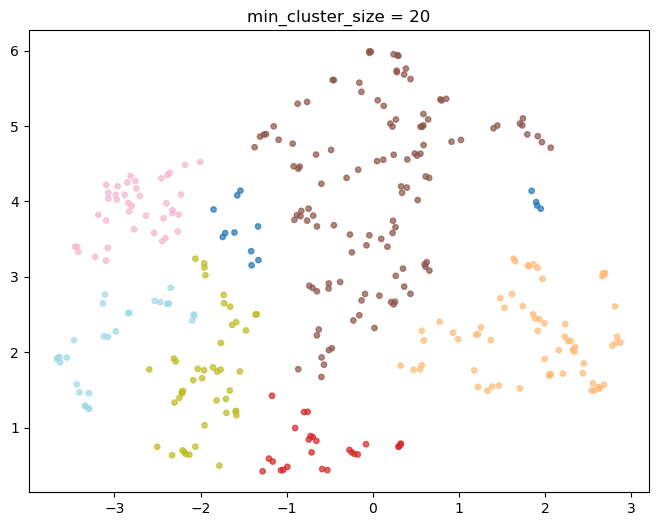

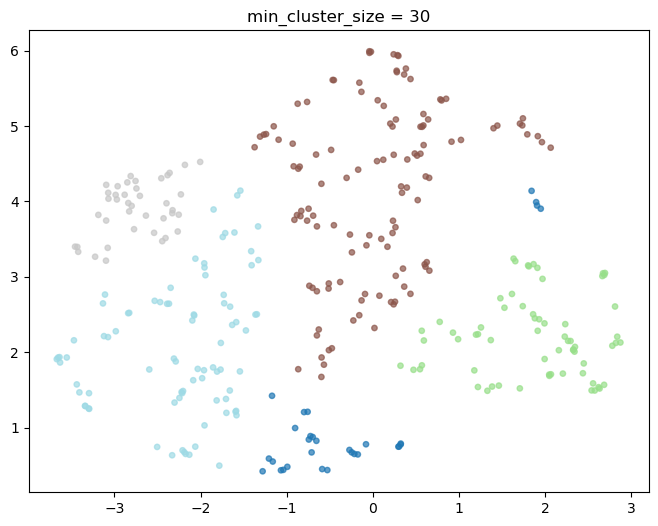

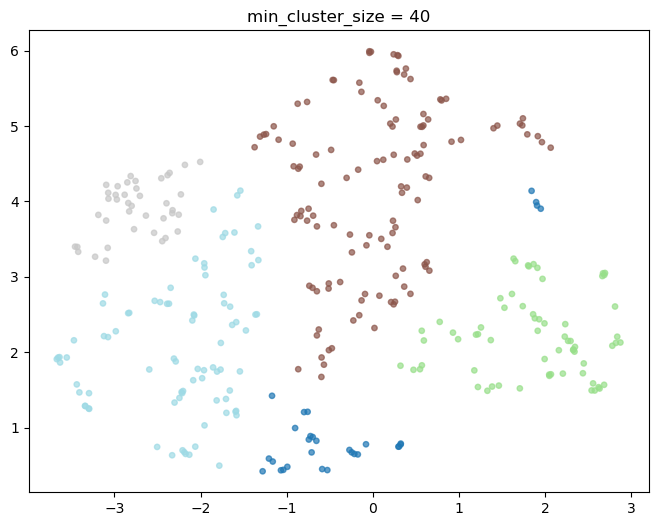

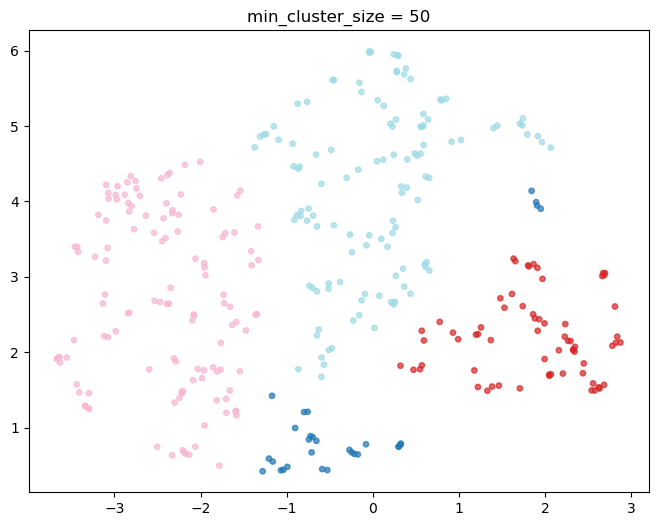

In [12]:
#Scatterplot - Minimum Cluster Size

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = min_size,
        min_samples = 1,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    labels = clusterer.labels_
    plt.figure(figsize = (8, 6))
    plt.scatter(
        umap_embeddings[:, 0],
        umap_embeddings[:, 1],
        c = labels,
        cmap = 'tab20',
        s = 15,
        alpha = 0.7)
    plt.title(f"min_cluster_size = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"Scatter_plot_cluster_{min_size}.png"))

plt.show()

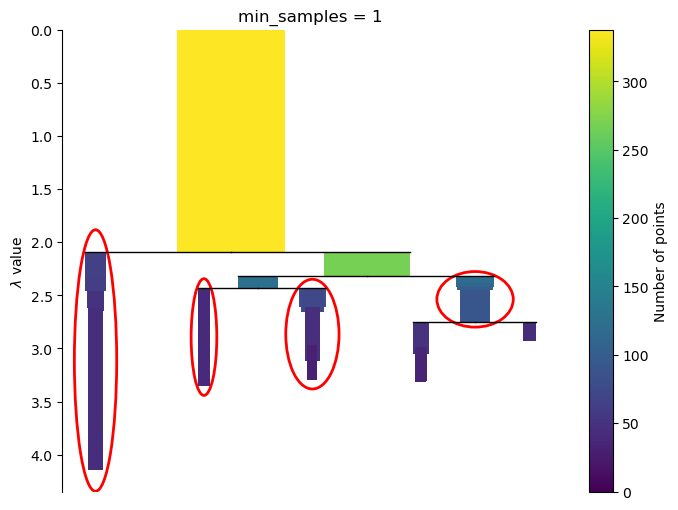

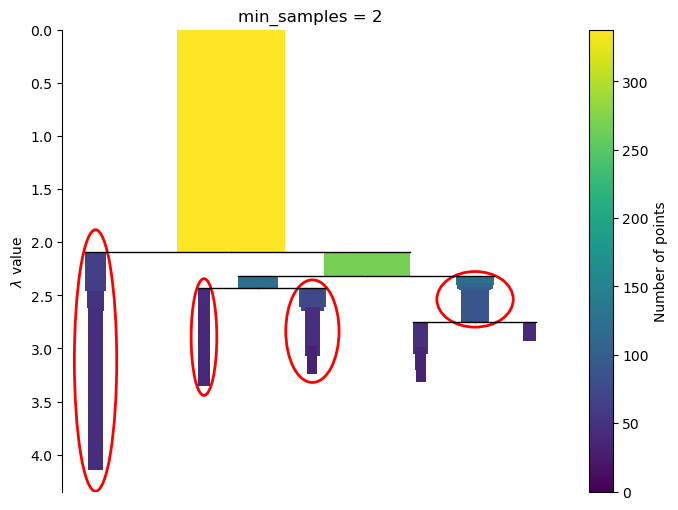

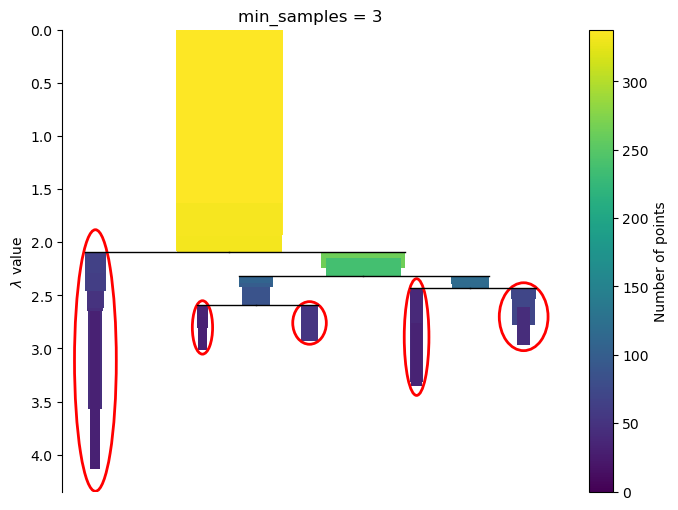

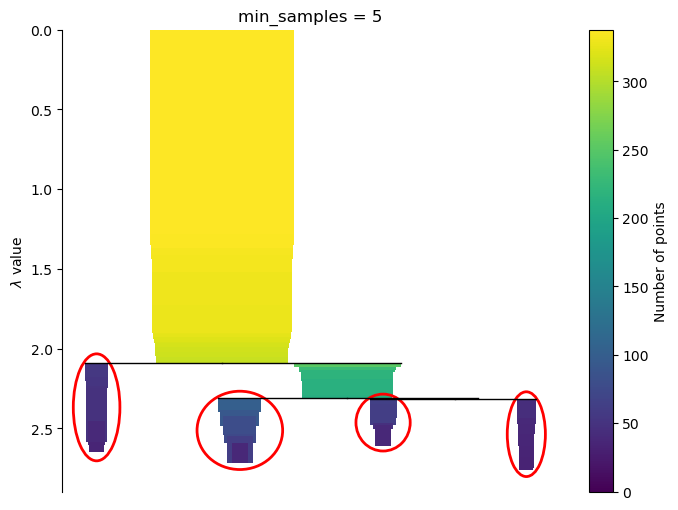

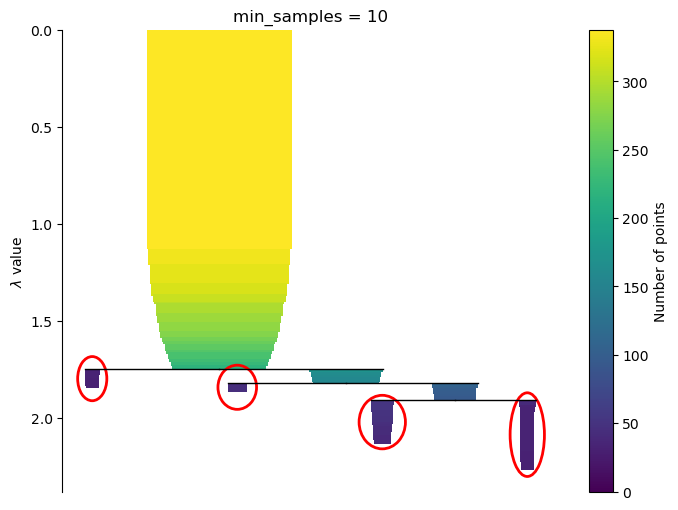

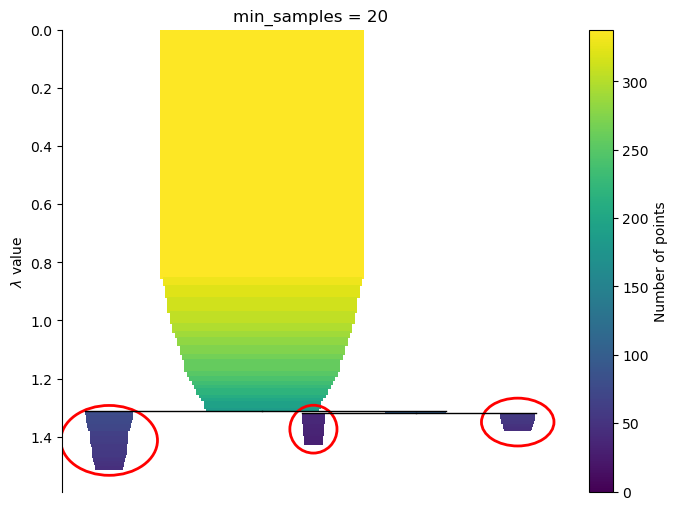

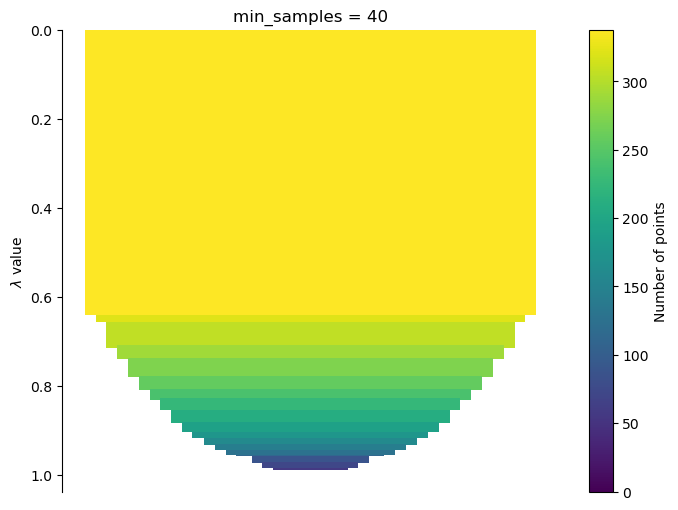

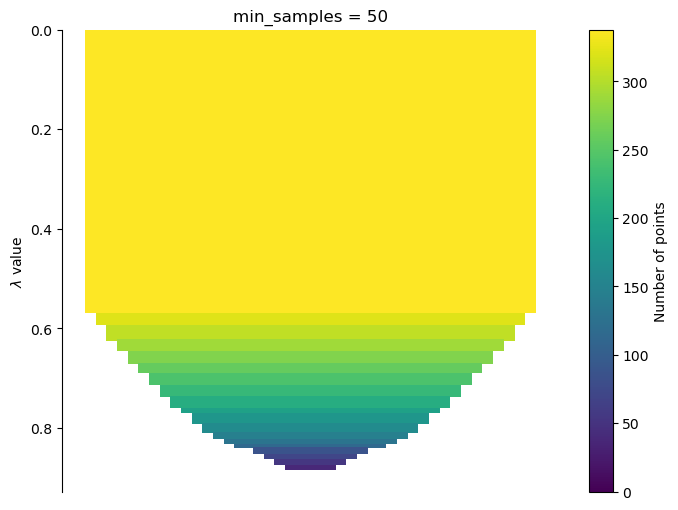

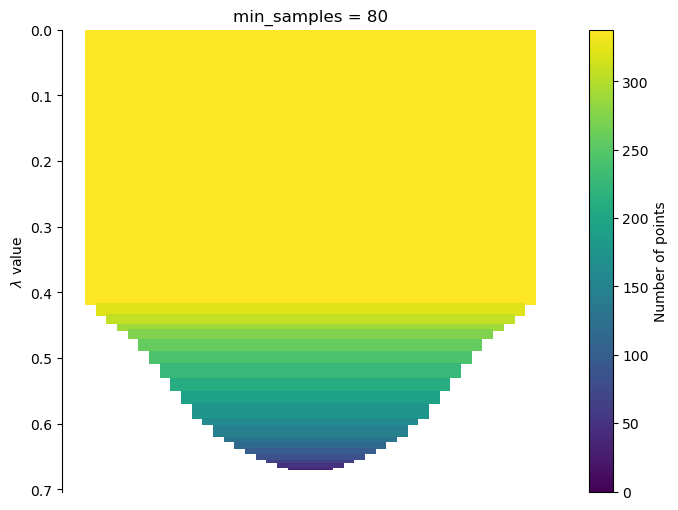

In [13]:
#Condensed Tree - Minimum Sample Size

min_sample_size = [1, 2, 3, 5, 10, 20, 40, 50, 80]

for min_size in min_sample_size:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = 30,
        min_samples = min_size,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    plt.figure(figsize = (8, 6))
    clusterer.condensed_tree_.plot(select_clusters = True)
    plt.title(f"min_samples = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"Condensed_tree_sample{min_size}.png"))

plt.show()

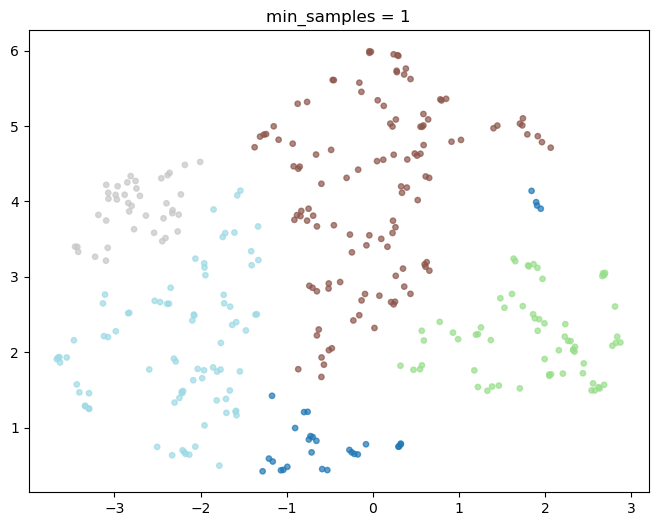

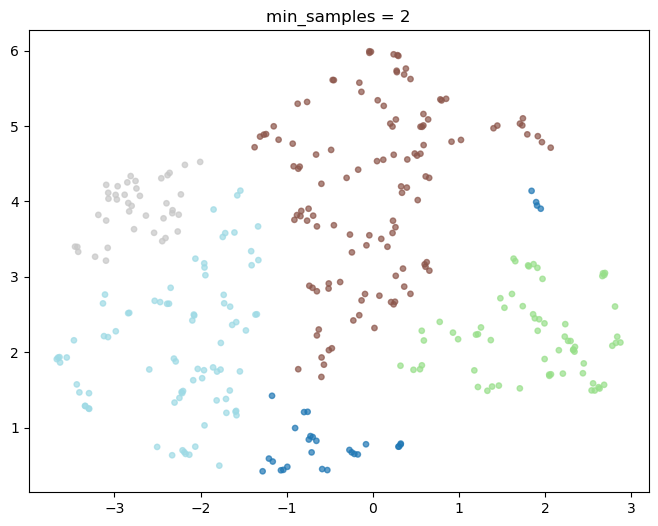

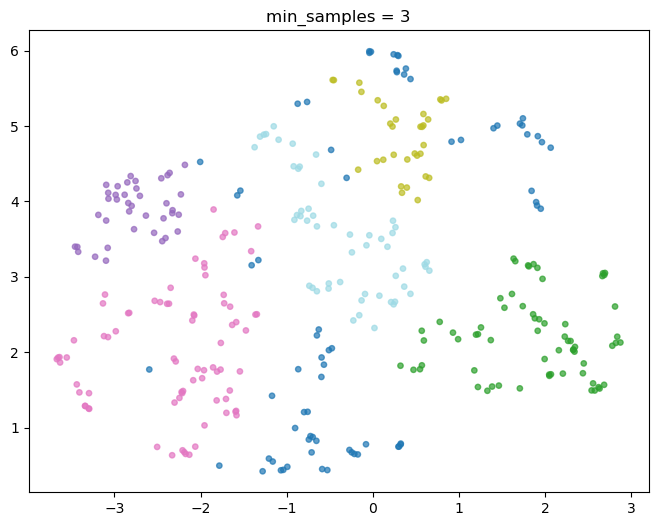

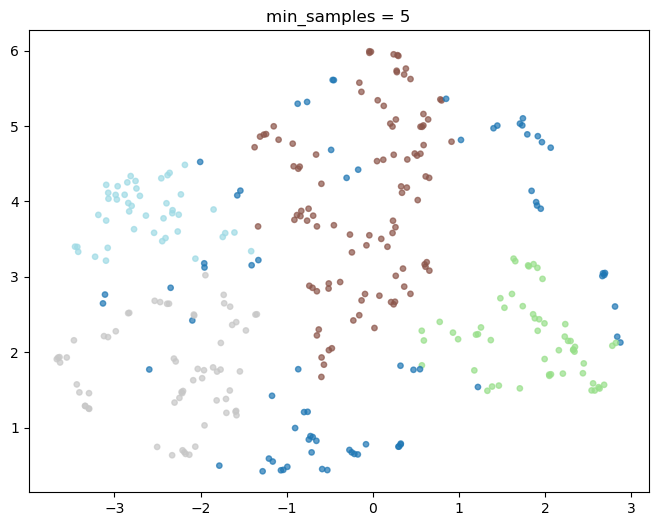

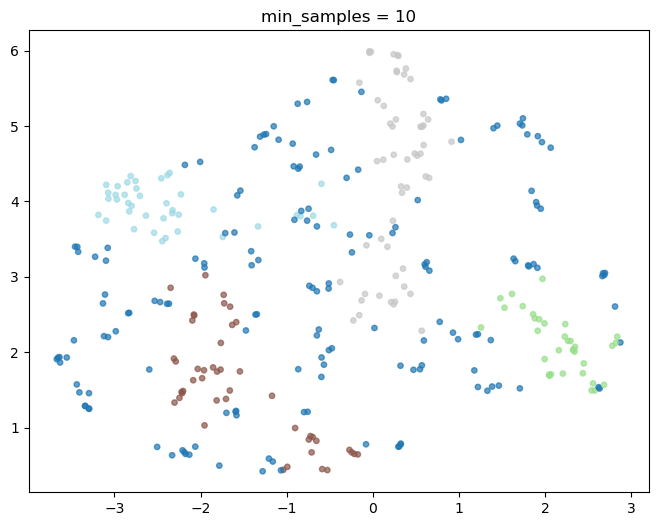

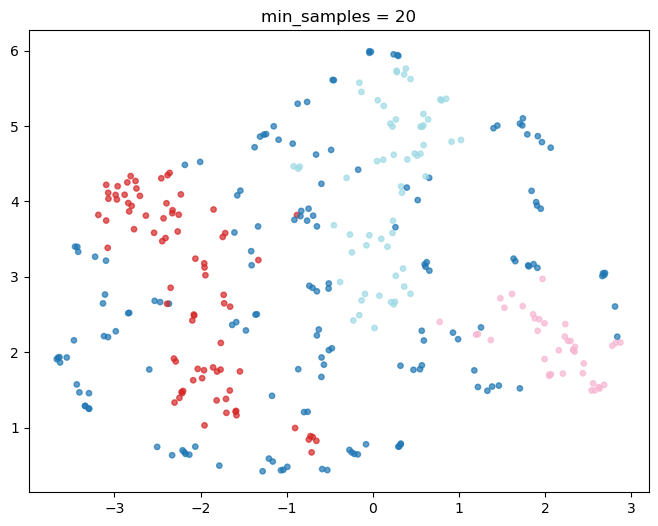

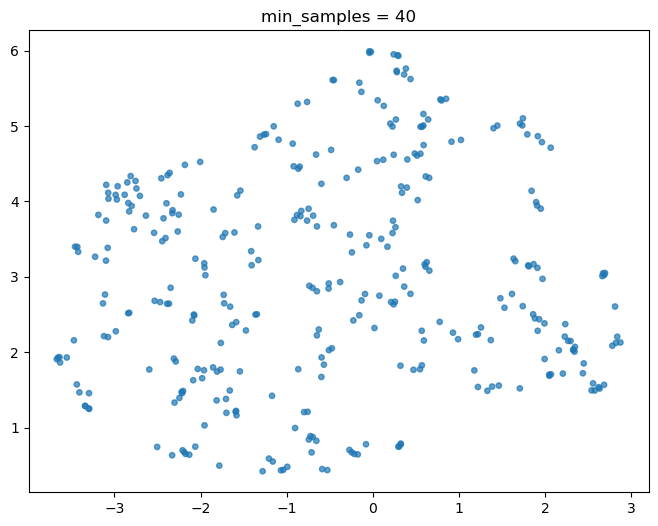

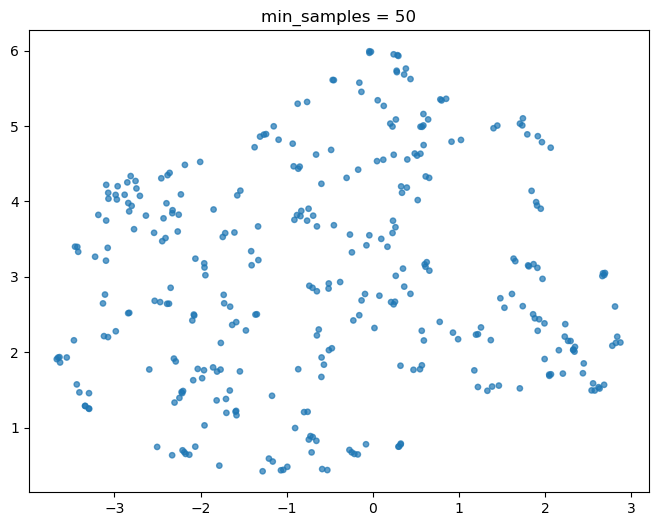

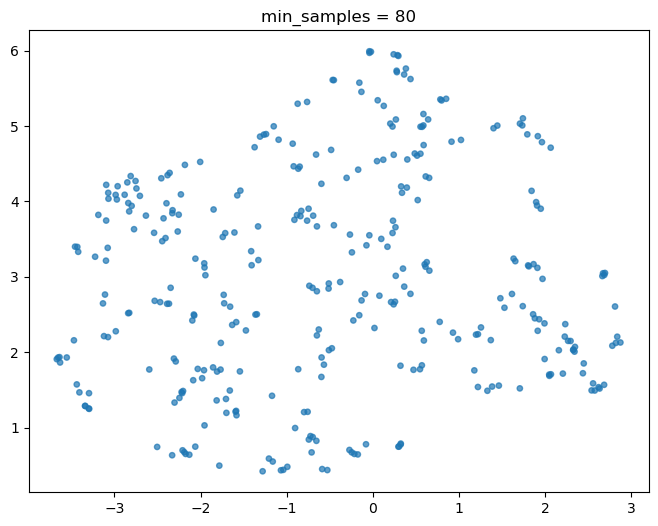

In [14]:
#Scatter plot - Minimum Sample Size

for min_size in min_sample_size:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size = 30,
        min_samples = min_size,
        metric = "euclidean",
        cluster_selection_method = "eom")
    clusterer.fit(umap_embeddings)
    labels = clusterer.labels_
    plt.figure(figsize = (8, 6))
    plt.scatter(
        umap_embeddings[:, 0],
        umap_embeddings[:, 1],
        c = labels,
        cmap = 'tab20',
        s = 15,
        alpha = 0.7)
    plt.title(f"min_samples = {min_size}")
#    plt.savefig(os.path.join(save_folder, f"scatter_plot_sample_{min_size}.png"))

plt.show()

In [15]:
#Final Model

clustering_model = hdbscan.HDBSCAN(min_cluster_size = 30, 
                                min_samples = 3,
                                metric = "euclidean",
                                cluster_selection_method = "eom") 

#### **Vectorisation**

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectoriser_model = CountVectorizer(ngram_range = (1, 2), min_df = 0.01, max_df = 0.8, stop_words = 'english')

#### **Representation**

In [17]:
from bertopic.representation import KeyBERTInspired

representation_model = KeyBERTInspired()

#### **BERTopic**

In [18]:
#Run Model
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model = embedding_model,
    umap_model = umap_model,
    hdbscan_model = clustering_model,
    vectorizer_model = vectoriser_model,
    representation_model = representation_model)

topics, probabilities = topic_model.fit_transform(text)

topic_info = topic_model.get_topic_info()

print(topic_info)

   Topic  Count                                               Name  \
0     -1     71   -1_social club_centenary hall_swindon_birmingham   
1      0     77  0_village hall_town hall_community association...   
2      1     66  1_leisure centre_rugby club_new clubhouse_whit...   
3      2     53  2_jubilee centre_city centre_community shop_bo...   
4      3     39  3_heritage hub_visitor centre_town hall_innova...   
5      4     32  4_stoke community_pub community_forge pub_vill...   

                                      Representation  \
0  [social club, centenary hall, swindon, birming...   
1  [village hall, town hall, community associatio...   
2  [leisure centre, rugby club, new clubhouse, wh...   
3  [jubilee centre, city centre, community shop, ...   
4  [heritage hub, visitor centre, town hall, inno...   
5  [stoke community, pub community, forge pub, vi...   

                                 Representative_Docs  
0  [Amar House Phase 1: The Slade Rooms   City's ...  
1  [Sa

In [19]:
topic_model.visualize_barchart()

### **Evaluation**

### *Clustering and HDBSCAN*

In [20]:
#Noise Ratio

noise_count = sum(1 for t in topics if t == 1)

noise_ratio = noise_count / 338

print(noise_ratio)

0.1952662721893491


### *Topic Evaluation*

In [21]:
#Topic Coherence

topic_model.visualize_documents(text)

In [22]:
#Overlap between Topics
topic_model.visualize_heatmap()

### *Label Evaluation*

In [ ]:
#F1, Precision, Recall, Accuracy

### *Substantive Evaluation*

In [23]:
#World Clouds
from wordcloud import WordCloud 

n_topics = len(topic_info) - 1

for topic_id in range(n_topics):
    word_probs = {word: prob for word, prob in topic_model.get_topic(topic_id)}
    wordcloud = WordCloud(width=400, height=200,
                          background_color='white',
                          prefer_horizontal=1.0).generate_from_frequencies(word_probs)
    ax = axes[topic_id // cols, topic_id % cols]
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Topic {topic_id}')

plt.tight_layout()
plt.show()

NameError: name 'axes' is not defined